# Setting up

In [ ]:
!pip install spacy transformers torch pandas matplotlib seaborn scikit-learn
!python -m spacy download pt_core_news_lg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 568.2/568.2 MB 2.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import json
import pandas as pd
import numpy as np
import spacy
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline, AutoTokenizer, AutoModel
from sklearn.manifold import TSNE

# 1. CARREGAMENTO DOS DADOS
with open('/content/drive/MyDrive/Colab Notebooks/signos.json', 'r', encoding='utf-8') as f:
    data = json.load(f)


In [ ]:
import re

# 1. IMPORTAÇÃO COMPLETA
# Em vez de criar a coluna 'texto' manualmente, passamos a lista de dicionários
# O Pandas transformará cada chave (ex: 'Como Áries é no Amor') em uma coluna
df = pd.DataFrame([info for signo, info in data.items()])

# Adicionamos a coluna do nome do signo (que estava na chave principal)
df.insert(0, 'Signo', [s.capitalize() for s in data.keys()])

# 2. FUNÇÃO DE PADRONIZAÇÃO (RENOVAR COLUNAS)
mapeamento = {
    'Jeito de ser': 'Perfil',
    'Amor': 'Amor',
    'beijo': 'Beijo',
    'Família': 'Família',
    'Trabalho': 'Trabalho',
    'Amizade': 'Amizade',
    'mãe ou pai': 'Parentalidade',
    'criança': 'Infância',
    'Saúde': 'Saúde',
    'Principais qualidade': 'Qualidades', # Pega 'Principais qualidade de [Signo]'
    'Defeitinhos': 'Defeitos',
    'motivos para amar': 'Motivos_Para_Amar'
}

def limpar_nome_coluna(col_name):
    for chave, novo_nome in mapeamento.items():
        if chave.lower() in col_name.lower():
            return novo_nome
    return col_name

# Aplicando a renomeação em todas as colunas do DataFrame
df.columns = [limpar_nome_coluna(c) for c in df.columns]

# 3. FILTRAGEM (OPCIONAL)
# Como o JSON tem muitas colunas (Salmo, Orixá, etc), podemos selecionar apenas as que padronizamos
colunas_desejadas = ['Signo', 'Elemento', 'Regente', 'Perfil', 'Amor', 'Beijo', 'Família',
                     'Trabalho', 'Amizade', 'Parentalidade', 'Infância', 'Saúde',
                     'Qualidades', 'Defeitos', 'Motivos_Para_Amar']

# Filtramos apenas as colunas que existem no mapeamento (evita erro se alguma faltar)
df_final = df[[c for c in colunas_desejadas if c in df.columns]]

In [ ]:
# 1. Agrupar colunas com o mesmo nome e combinar os valores
# O método 'first' pega o primeiro valor não-nulo encontrado em cada linha
df_consolidado = df.groupby(level=0, axis=1).first()

# 2. Reordenar as colunas para facilitar a leitura
colunas_ordem = ['Signo', 'Elemento', 'Perfil', 'Amor', 'Beijo', 'Trabalho',
                 'Família', 'Amizade', 'Qualidades', 'Defeitos']

# Pegamos apenas as colunas que realmente existem após a consolidação
colunas_finais = [c for c in colunas_ordem if c in df_consolidado.columns]
df_final = df_consolidado[colunas_finais]

# 3. Verificação
print(f"Colunas após consolidar: {df_final.columns.tolist()}")
display(df_final.head())

Colunas após consolidar: ['Signo', 'Elemento', 'Perfil', 'Amor', 'Beijo', 'Trabalho', 'Família', 'Amizade', 'Qualidades', 'Defeitos']


/tmp/ipykernel_14689/1256792664.py:3: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  df_consolidado = df.groupby(level=0, axis=1).first()


,Signo,Elemento,Perfil,Amor,Beijo,Trabalho,Família,Amizade,Qualidades,Defeitos
0,Aries,Fogo,"Áries é o primeiro signo do Zodíaco, o que exp...",A impetuosidade com que se lança na estrada da...,É um beijo cheio de vontade e calor! Também é ...,Seus principais atributos – a coragem e o dina...,"Em família, você gosta de dar a última palavra...","Em família, você gosta de dar a última palavra...","[Dinamismo, Coragem, Independência, Entusiasmo...","[Impaciência, Egoísmo, Agressividade, Orgulho,..."
1,Touro,Terra,A frase “Devagar se vai ao longe” deveria faze...,"Para ser feliz no amor, Touro precisa, sobretu...","Como a sensualidade corre nas suas veias, seu ...","Na vida profissional, você se destaca pela cap...",É na sua casa que você se sente livre para des...,"Para Touro, amizade é para vida toda! Por isso...","[Determinação, Paciência, Persistência, Sensat...","[Teimosia, Possessividade, Inflexibilidade, Te..."
2,Gemeos,Ar,"Dentro das suas veias, correm a curiosidade, a...","Antes de se envolver com alguém, você precisa ...",Geminianos nunca beijam da mesma forma: num de...,A criatividade é sua principal arma no mercado...,Você não deixa a peteca cair em casa! Mesmo qu...,"Seu esporte preferido é fazer amizades, Gêmeos...","[Poder de comunicação, Curiosidade, Otimismo, ...","[Inconstância, Indiscrição, Superficialidade, ..."
3,Cancer,Água,"Sensibilidade, sentimento, saudosismo, intuiçã...",O eixo da sua vida é a estabilidade no amor. P...,Seu beijo não tem hora para acabar: você gosta...,A sua percepção privilegiada é seu diferencial...,"Como a família é o norte da sua vida, é no con...","Sua lista de amigos não é grande. Na verdade, ...","[Intuição, Sensibilidade, Instinto de proteção...","[Dependência emocional, Insegurança, Possessiv..."
4,Leao,Fogo,Da mesma forma que o rugido do leão faz a selv...,"Para Leão, o amor ideal deve ter sabor de desc...","Seu beijo é cheio de desejo e calor, já que Le...",Você encara o trabalho como um campo aberto pa...,"Junto à família, Leão não foge da sua essência...","Você adora a companhia dos amigos, porque a pr...","[1.Poder de sedução, Carisma, Otimismo, Genero...","[Vaidade, Arrogância, Egoísmo, Orgulho, Preguiça]"


In [ ]:
df_final.columns

Index(['Signo', 'Elemento', 'Perfil', 'Amor', 'Beijo', 'Trabalho', 'Família',
       'Amizade', 'Qualidades', 'Defeitos'],
      dtype='object')

# NLP

In [ ]:
# 2. CONFIGURAÇÃO DAS FERRAMENTAS
# Carrega spaCy para PLN
nlp = spacy.load("pt_core_news_lg")

# Carrega Transformers para Sentimento e Embeddings
sentiment_pipe = pipeline("sentiment-analysis", model="nlptown/bert-base-multilingual-uncased-sentiment")
embed_tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")
embed_model = AutoModel.from_pretrained("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

# 3. PROCESSAMENTO LINGUÍSTICO E SENTIMENTO
def processar_dados(texto):
    doc = nlp(texto)

    # NLP com spaCy
    tokens = [t.text for t in doc]
    lemas = [t.lemma_ for t in doc if not t.is_stop and t.is_alpha]
    pos = [t.pos_ for t in doc]
    entidades = [(ent.text, ent.label_) for ent in doc.ents]
    chunks = [chunk.text for chunk in doc.noun_chunks]
    sentencas = [sent.text for sent in doc.sents]

    # Sentimento (Transformers)
    sent_res = sentiment_pipe(texto[:512])[0]
    score = int(sent_res['label'].split()[0])

    # Embeddings (Transformers)
    inputs = embed_tokenizer(texto, return_tensors="pt", truncation=True, padding=True, max_length=512)
    with torch.no_grad():
        outputs = embed_model(**inputs)
    embedding = outputs.last_hidden_state.mean(dim=1).numpy().flatten()

    return pd.Series([lemas, entidades, chunks, sentencas, score, embedding])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Perfil (Jeito de Ser)

In [ ]:
print("Processando PLN, Sentimentos e Embeddings... aguarde.")
# Aplicando a função e criando as colunas explicitamente
df[['lemas', 'entidades', 'noun_chunks', 'sentencas', 'sentimento_score', 'embeddings']] = df['Perfil'].apply(processar_dados)

Processando PLN, Sentimentos e Embeddings... aguarde.


/tmp/ipykernel_14689/1667965439.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[['lemas', 'entidades', 'noun_chunks', 'sentencas', 'sentimento_score', 'embeddings']] = df['Perfil'].apply(processar_dados)


/tmp/ipykernel_14689/3890838734.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Signo', y='sentimento_score', data=df, palette='magma')


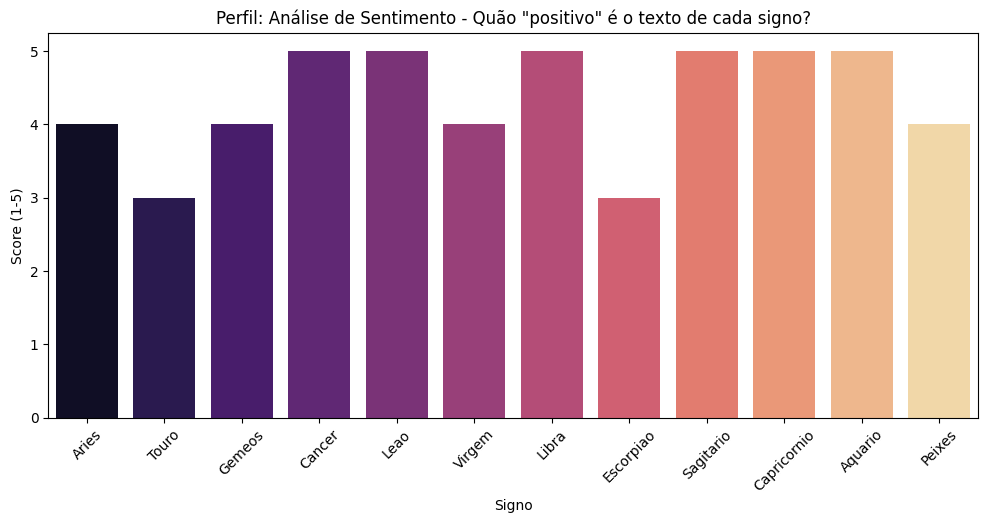

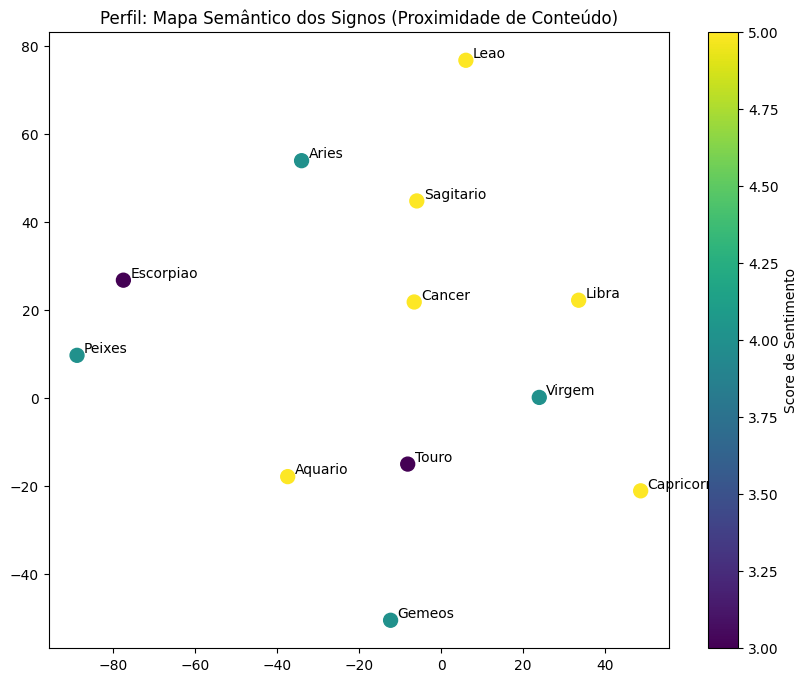

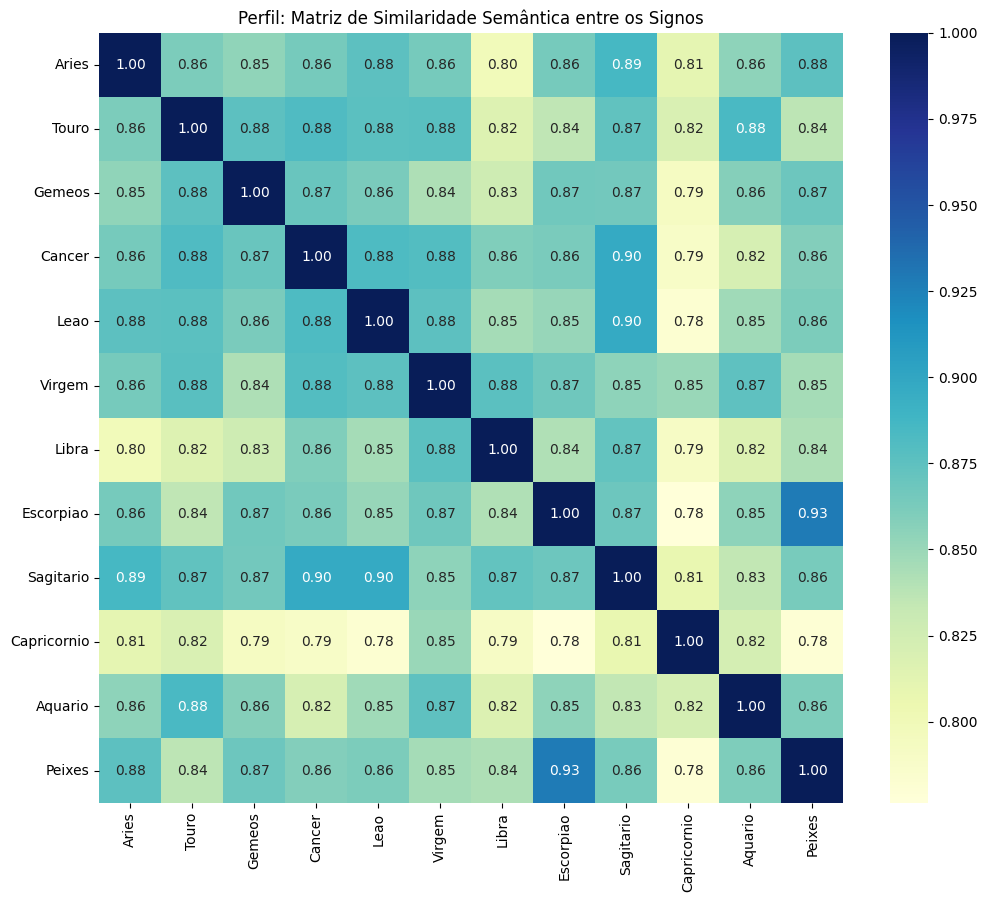

In [ ]:
# 4. VISUALIZAÇÃO - GRÁFICO DE SENTIMENTOS (Amor)
plt.figure(figsize=(12, 5))
sns.barplot(x='Signo', y='sentimento_score', data=df, palette='magma')
plt.title('Perfil: Análise de Sentimento - Quão "positivo" é o texto de cada signo?')
plt.ylabel('Score (1-5)')
plt.xticks(rotation=45)
plt.show()
# 5. VISUALIZAÇÃO - MAPA SEMÂNTICO (TSNE)
# CORREÇÃO AQUI: Convertendo a lista de embeddings em uma matriz NumPy 2D
matrix_embeddings = np.vstack(df['embeddings'].values)

# Redução de dimensionalidade
tsne = TSNE(n_components=2, random_state=42, perplexity=min(5, len(df)-1), init='pca', learning_rate='auto')
vis_dims = tsne.fit_transform(matrix_embeddings)

plt.figure(figsize=(10, 8))
plt.scatter(vis_dims[:, 0], vis_dims[:, 1], c=df['sentimento_score'], cmap='viridis', s=100)

# Adicionar rótulos aos pontos
for i, signo in enumerate(df['Signo']):
    plt.annotate(signo, (vis_dims[i, 0], vis_dims[i, 1]), xytext=(5, 2), textcoords='offset points')

plt.title('Perfil: Mapa Semântico dos Signos (Proximidade de Conteúdo)')
plt.colorbar(label='Score de Sentimento')
plt.show()

from sklearn.metrics.pairwise import cosine_similarity

# 1. Calcular a matriz de similaridade entre todos os embeddings
# np.stack transforma a coluna de listas em uma matriz 2D
sim_matrix = cosine_similarity(np.stack(df['embeddings'].values))

# 2. Criar o Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(sim_matrix, annot=True, fmt=".2f", cmap='YlGnBu',
            xticklabels=df['Signo'].values,
            yticklabels=df['Signo'].values)

plt.title('Perfil: Matriz de Similaridade Semântica entre os Signos')
plt.show()

## Amor

In [ ]:
print("Processando PLN, Sentimentos e Embeddings... aguarde.")

# Aplicando a função e criando as colunas explicitamente

df_final[['lemas', 'entidades', 'noun_chunks', 'sentencas', 'sentimento_score', 'embeddings']] = df_final['Amor'].apply(processar_dados)

Processando PLN, Sentimentos e Embeddings... aguarde.


/tmp/ipykernel_14689/479209251.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final[['lemas', 'entidades', 'noun_chunks', 'sentencas', 'sentimento_score', 'embeddings']] = df_final['Amor'].apply(processar_dados)
/tmp/ipykernel_14689/479209251.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final[['lemas', 'entidades', 'noun_chunks', 'sentencas', 'sentimento_score', 'embeddings']] = df_final['Amor'].apply(processar_dados)
/tmp/ipykernel_14689/479209251.py:5: SettingWithCopyWarning: 
A value is

In [ ]:
print("Processando PLN, Sentimentos e Embeddings sobre o perfil completo... aguarde.")

# Agora passamos apenas a coluna 'texto_para_ia'
df_results = df_final['Amor'].apply(processar_dados)

# Criando as novas colunas no DataFrame original
df_final[['lemas', 'entidades', 'noun_chunks', 'sentencas', 'sentimento_score', 'embeddings']] = df_results

print("Concluído!")

Processando PLN, Sentimentos e Embeddings sobre o perfil completo... aguarde.
Concluído!


/tmp/ipykernel_14689/4174536285.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final[['lemas', 'entidades', 'noun_chunks', 'sentencas', 'sentimento_score', 'embeddings']] = df_results


In [ ]:
df = df_final

/tmp/ipykernel_14689/3949262031.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Signo', y='sentimento_score', data=df, palette='magma')


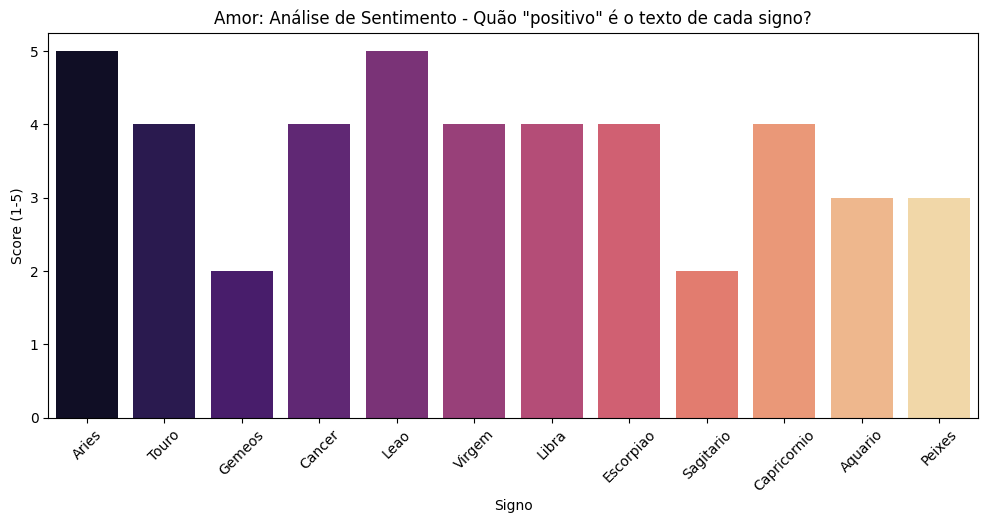

/tmp/ipykernel_14689/2877368981.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Signo', y='sentimento_score', data=df, palette='magma')


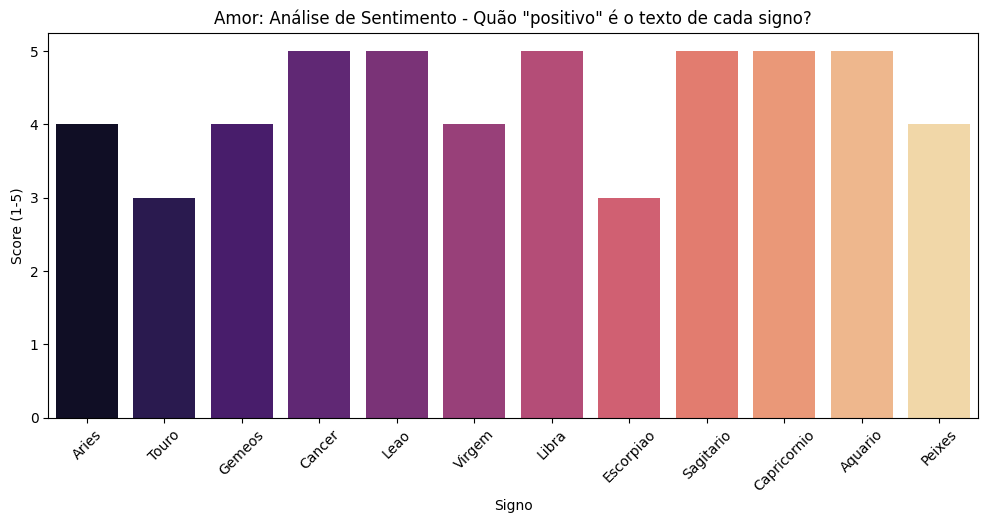

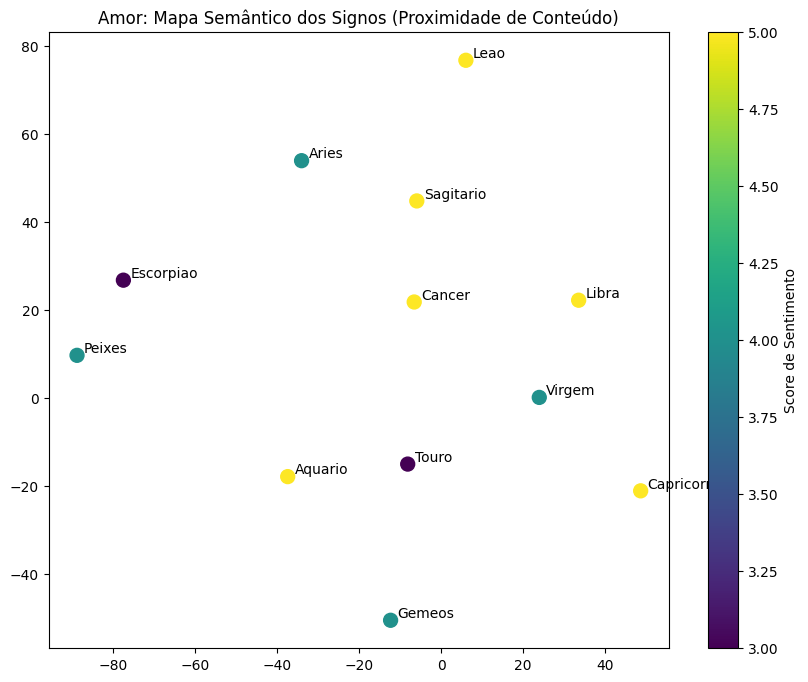


EXEMPLO DE PROCESSAMENTO DE LINGUAGEM NATURAL (Áries)
Signo: Aries

1. Sentenças (primeiras 2): ['Áries é o primeiro signo do Zodíaco, o que explica muita coisa sobre a sua vibrante personalidade.', 'Você gosta de decidir, dominar o romance, liderar sua equipe de trabalho.']

2. Entidades Nomeadas (NER): [('Zodíaco', 'PER'), ('Adora', 'PER'), ('Marte', 'LOC'), ('Áries', 'PER')]

3. Noun Chunks (primeiros 5): ['Áries', 'Zodíaco', 'o', 'que', 'muita coisa']

4. Lemas (primeiros 10 sem stopwords): ['Áries', 'signo', 'Zodíaco', 'explicar', 'muito', 'vibrante', 'personalidade', 'gostar', 'decidir', 'dominar']


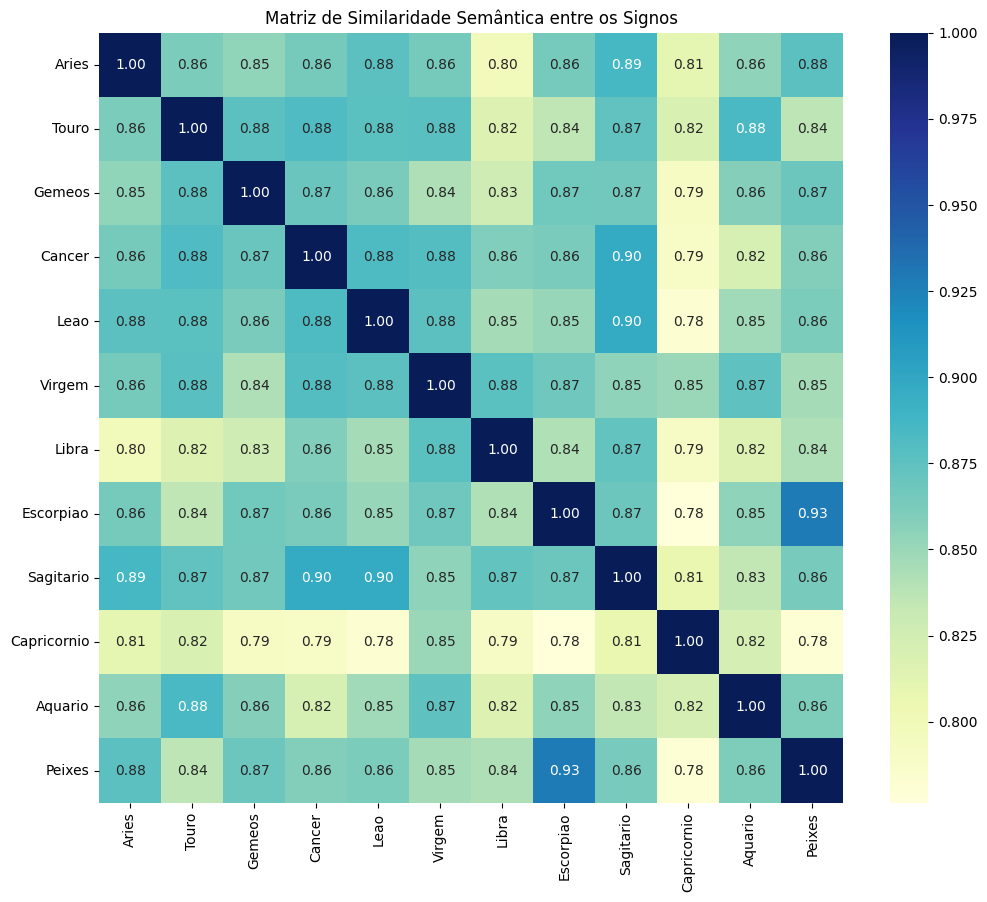

In [ ]:
# 4. VISUALIZAÇÃO - GRÁFICO DE SENTIMENTOS (Amor)
plt.figure(figsize=(12, 5))
sns.barplot(x='Signo', y='sentimento_score', data=df, palette='magma')
plt.title('Amor: Análise de Sentimento - Quão "positivo" é o texto de cada signo?')
plt.ylabel('Score (1-5)')
plt.xticks(rotation=45)
plt.show()

# 5. VISUALIZAÇÃO - MAPA SEMÂNTICO (TSNE)
# CORREÇÃO AQUI: Convertendo a lista de embeddings em uma matriz NumPy 2D
matrix_embeddings = np.vstack(df['embeddings'].values)

# Redução de dimensionalidade
tsne = TSNE(n_components=2, random_state=42, perplexity=min(5, len(df)-1), init='pca', learning_rate='auto')
vis_dims = tsne.fit_transform(matrix_embeddings)

plt.figure(figsize=(10, 8))
plt.scatter(vis_dims[:, 0], vis_dims[:, 1], c=df['sentimento_score'], cmap='viridis', s=100)

# Adicionar rótulos aos pontos
for i, signo in enumerate(df['Signo']):
    plt.annotate(signo, (vis_dims[i, 0], vis_dims[i, 1]), xytext=(5, 2), textcoords='offset points')

plt.title('Amor: Mapa Semântico dos Signos (Proximidade de Conteúdo)')
plt.colorbar(label='Score de Sentimento')
plt.show()

# 6. DEMONSTRAÇÃO DOS RESULTADOS DE PLN
print("\n" + "="*50)
print("EXEMPLO DE PROCESSAMENTO DE LINGUAGEM NATURAL (Áries)")
print("="*50)
exemplo = df.iloc[0]
print(f"Signo: {exemplo['Signo']}")
print(f"\n1. Sentenças (primeiras 2): {exemplo['sentencas'][:2]}")
print(f"\n2. Entidades Nomeadas (NER): {exemplo['entidades']}")
print(f"\n3. Noun Chunks (primeiros 5): {exemplo['noun_chunks'][:5]}")
print(f"\n4. Lemas (primeiros 10 sem stopwords): {exemplo['lemas'][:10]}")

from sklearn.metrics.pairwise import cosine_similarity

# 1. Calcular a matriz de similaridade entre todos os embeddings
# np.stack transforma a coluna de listas em uma matriz 2D
sim_matrix = cosine_similarity(np.stack(df['embeddings'].values))

# 2. Criar o Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(sim_matrix, annot=True, fmt=".2f", cmap='YlGnBu',
            xticklabels=df['Signo'].values,
            yticklabels=df['Signo'].values)

plt.title('Matriz de Similaridade Semântica entre os Signos')
plt.show()

# Observação pro grupo: uma ideia é a gente ir fazendo de varias categorias e comparar as diferenças

## Trabalho

In [ ]:
print("Processando PLN, Sentimentos e Embeddings... aguarde.")

# Aplicando a função e criando as colunas explicitamente

df_final[['lemas', 'entidades', 'noun_chunks', 'sentencas', 'sentimento_score', 'embeddings']] = df_final['Trabalho'].apply(processar_dados)

Processando PLN, Sentimentos e Embeddings... aguarde.


/tmp/ipykernel_14689/1243169426.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final[['lemas', 'entidades', 'noun_chunks', 'sentencas', 'sentimento_score', 'embeddings']] = df_final['Trabalho'].apply(processar_dados)


In [ ]:
print("Processando PLN, Sentimentos e Embeddings sobre o perfil completo... aguarde.")

# Agora passamos apenas a coluna 'texto_para_ia'
df_results = df_final['Trabalho'].apply(processar_dados)

# Criando as novas colunas no DataFrame original
df_final[['lemas', 'entidades', 'noun_chunks', 'sentencas', 'sentimento_score', 'embeddings']] = df_results

print("Concluído!")

Processando PLN, Sentimentos e Embeddings sobre o perfil completo... aguarde.
Concluído!


/tmp/ipykernel_14689/1509987185.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final[['lemas', 'entidades', 'noun_chunks', 'sentencas', 'sentimento_score', 'embeddings']] = df_results


In [ ]:
df = df_final

/tmp/ipykernel_14689/892448325.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Signo', y='sentimento_score', data=df, palette='magma')


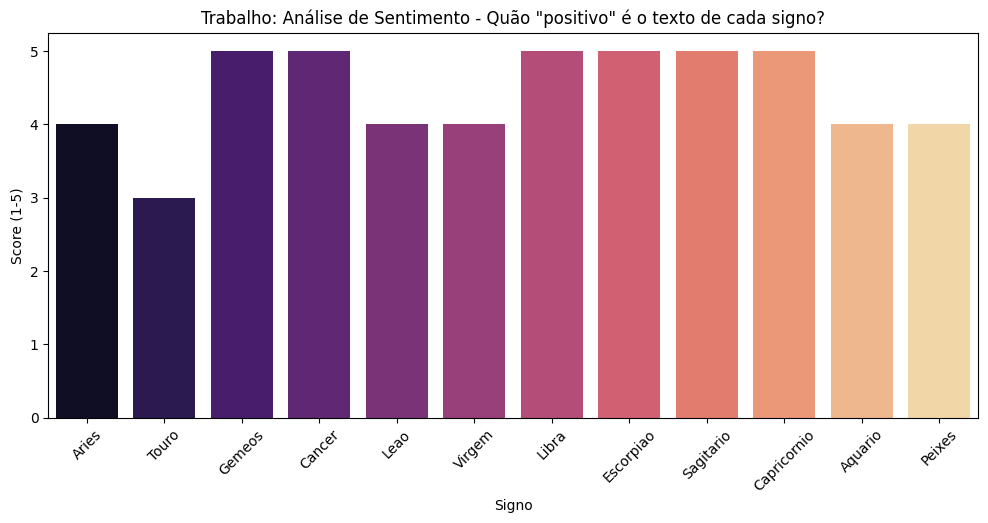

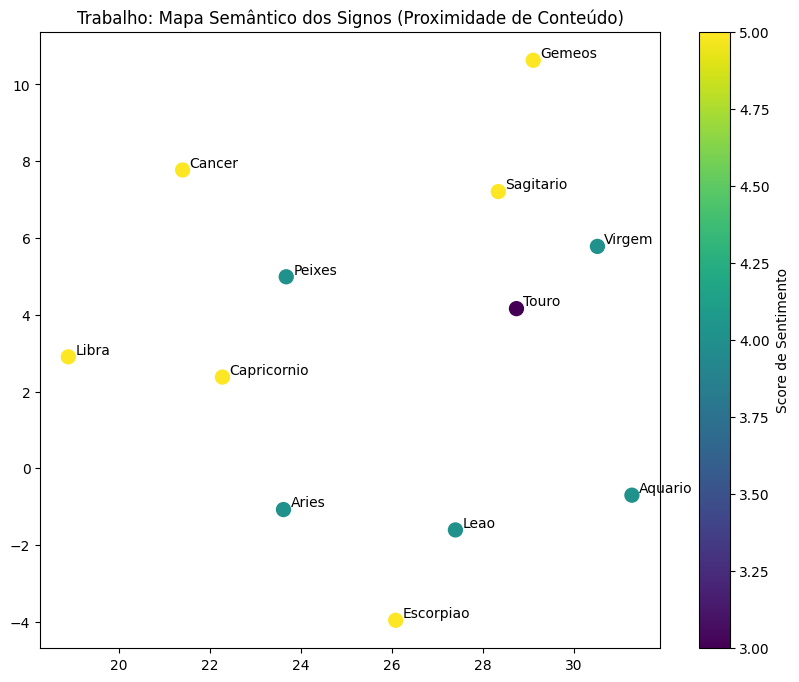


EXEMPLO DE PROCESSAMENTO DE LINGUAGEM NATURAL (Áries)
Signo: Aries

1. Sentenças (primeiras 2): ['Seus principais atributos – a coragem e o dinamismo – são seus diferenciais na vida profissional.', 'Eles que levam você a abraçar posições de comando e a transformar ideias em empreendimentos reais.']

2. Entidades Nomeadas (NER): []

3. Noun Chunks (primeiros 5): ['Seus principais atributos', '– a coragem', 'o dinamismo', 'vida profissional', 'Eles']

4. Lemas (primeiros 10 sem stopwords): ['principal', 'atributo', 'coragem', 'dinamismo', 'diferencial', 'vida', 'profissional', 'levar', 'abraçar', 'posição']


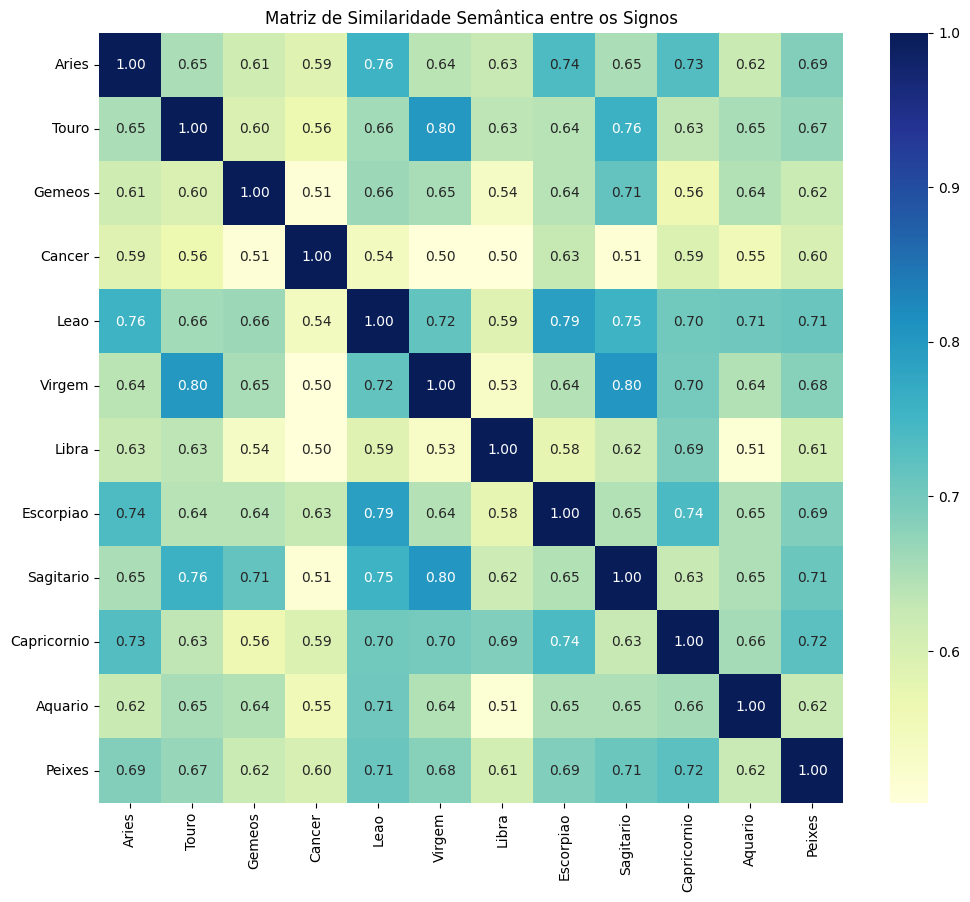

In [ ]:
# 4. VISUALIZAÇÃO - GRÁFICO DE SENTIMENTOS (Trabalho)
plt.figure(figsize=(12, 5))
sns.barplot(x='Signo', y='sentimento_score', data=df, palette='magma')
plt.title('Trabalho: Análise de Sentimento - Quão "positivo" é o texto de cada signo?')
plt.ylabel('Score (1-5)')
plt.xticks(rotation=45)
plt.show()

# 5. VISUALIZAÇÃO - MAPA SEMÂNTICO (TSNE)
# CORREÇÃO AQUI: Convertendo a lista de embeddings em uma matriz NumPy 2D
matrix_embeddings = np.vstack(df['embeddings'].values)

# Redução de dimensionalidade
tsne = TSNE(n_components=2, random_state=42, perplexity=min(5, len(df)-1), init='pca', learning_rate='auto')
vis_dims = tsne.fit_transform(matrix_embeddings)

plt.figure(figsize=(10, 8))
plt.scatter(vis_dims[:, 0], vis_dims[:, 1], c=df['sentimento_score'], cmap='viridis', s=100)

# Adicionar rótulos aos pontos
for i, signo in enumerate(df['Signo']):
    plt.annotate(signo, (vis_dims[i, 0], vis_dims[i, 1]), xytext=(5, 2), textcoords='offset points')

plt.title('Trabalho: Mapa Semântico dos Signos (Proximidade de Conteúdo)')
plt.colorbar(label='Score de Sentimento')
plt.show()

# 6. DEMONSTRAÇÃO DOS RESULTADOS DE PLN
print("\n" + "="*50)
print("EXEMPLO DE PROCESSAMENTO DE LINGUAGEM NATURAL (Áries)")
print("="*50)
exemplo = df.iloc[0]
print(f"Signo: {exemplo['Signo']}")
print(f"\n1. Sentenças (primeiras 2): {exemplo['sentencas'][:2]}")
print(f"\n2. Entidades Nomeadas (NER): {exemplo['entidades']}")
print(f"\n3. Noun Chunks (primeiros 5): {exemplo['noun_chunks'][:5]}")
print(f"\n4. Lemas (primeiros 10 sem stopwords): {exemplo['lemas'][:10]}")

from sklearn.metrics.pairwise import cosine_similarity

# 1. Calcular a matriz de similaridade entre todos os embeddings
# np.stack transforma a coluna de listas em uma matriz 2D
sim_matrix = cosine_similarity(np.stack(df['embeddings'].values))

# 2. Criar o Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(sim_matrix, annot=True, fmt=".2f", cmap='YlGnBu',
            xticklabels=df['Signo'].values,
            yticklabels=df['Signo'].values)

plt.title('Matriz de Similaridade Semântica entre os Signos')
plt.show()

## Tristeza (Defeitos)

Nesta seção analisamos a coluna **Defeitos** de cada signo — os textos com teor mais negativo,
associados semanticamente à tristeza, insatisfação e falhas. Usamos paleta fria/azul para reforçar o tema.

In [ ]:
print("Processando PLN, Sentimentos e Embeddings para Tristeza (Defeitos)... aguarde.")

# Aplicando a função na coluna 'Defeitos'
df_final[['lemas', 'entidades', 'noun_chunks', 'sentencas', 'sentimento_score', 'embeddings']] = df_final['Defeitos'].apply(processar_dados)

print("Concluído!")

In [ ]:
print("Reprocessando para garantir consistência...")

df_results = df_final['Defeitos'].apply(processar_dados)
df_final[['lemas', 'entidades', 'noun_chunks', 'sentencas', 'sentimento_score', 'embeddings']] = df_results

print("Concluído!")

In [ ]:
df = df_final

In [ ]:
# 4. VISUALIZAÇÃO - GRÁFICO DE SENTIMENTOS (Tristeza / Defeitos)
plt.figure(figsize=(12, 5))
sns.barplot(x='Signo', y='sentimento_score', data=df,
            palette='Blues_d',  # Paleta fria para remeter à tristeza
            hue='Signo', legend=False)
plt.title('Tristeza (Defeitos): Análise de Sentimento — Quão "negativo" é o texto de cada signo?')
plt.ylabel('Score (1-5)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 5. VISUALIZAÇÃO - MAPA SEMÂNTICO (TSNE)
matrix_embeddings = np.vstack(df['embeddings'].values)

tsne = TSNE(n_components=2, random_state=42, perplexity=min(5, len(df)-1), init='pca', learning_rate='auto')
vis_dims = tsne.fit_transform(matrix_embeddings)

plt.figure(figsize=(10, 8))
plt.scatter(vis_dims[:, 0], vis_dims[:, 1],
            c=df['sentimento_score'], cmap='Blues_r', s=120, edgecolors='navy', linewidths=0.5)

for i, signo in enumerate(df['Signo']):
    plt.annotate(signo, (vis_dims[i, 0], vis_dims[i, 1]), xytext=(5, 2), textcoords='offset points')

plt.title('Tristeza (Defeitos): Mapa Semântico dos Signos (Proximidade de Conteúdo)')
plt.colorbar(label='Score de Sentimento')
plt.tight_layout()
plt.show()

# 6. DEMONSTRAÇÃO DOS RESULTADOS DE PLN
print("\n" + "="*50)
print("EXEMPLO DE PROCESSAMENTO DE LINGUAGEM NATURAL — TRISTEZA (Áries)")
print("="*50)
exemplo = df.iloc[0]
print(f"Signo: {exemplo['Signo']}")
print(f"\n1. Sentenças (primeiras 2): {exemplo['sentencas'][:2]}")
print(f"\n2. Entidades Nomeadas (NER): {exemplo['entidades']}")
print(f"\n3. Noun Chunks (primeiros 5): {exemplo['noun_chunks'][:5]}")
print(f"\n4. Lemas (primeiros 10 sem stopwords): {exemplo['lemas'][:10]}")

from sklearn.metrics.pairwise import cosine_similarity

sim_matrix = cosine_similarity(np.stack(df['embeddings'].values))

# 7. HEATMAP DE SIMILARIDADE SEMÂNTICA
plt.figure(figsize=(12, 10))
sns.heatmap(sim_matrix, annot=True, fmt=".2f", cmap='Blues',
            xticklabels=df['Signo'].values,
            yticklabels=df['Signo'].values)

plt.title('Tristeza (Defeitos): Matriz de Similaridade Semântica entre os Signos')
plt.tight_layout()
plt.show()

# 8. ANÁLISE EXTRA: Top lemas mais frequentes (palavras negativas predominantes)
from collections import Counter
import itertools

todos_lemas = list(itertools.chain.from_iterable(df['lemas'].dropna()))
freq = Counter(todos_lemas).most_common(20)
palavras, contagens = zip(*freq)

plt.figure(figsize=(12, 5))
sns.barplot(x=list(palavras), y=list(contagens),
            hue=list(palavras), palette='mako', legend=False)
plt.title('Tristeza (Defeitos): 20 Lemas Mais Frequentes nos Textos de Defeitos')
plt.ylabel('Frequência')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Observações sobre Tristeza (Defeitos)

- Signos com **score de sentimento mais baixo** possuem textos de defeitos com linguagem mais negativa/intensa.
- O **mapa semântico (t-SNE)** revela agrupamentos por elemento ou modalidade (signos fixos, cardinais, mutáveis).
- O **heatmap de similaridade** evidencia quais signos compartilham vocabulário de fraquezas semelhante.
- O **gráfico de lemas** mostra as palavras-chave que dominam semanticamente o campo da tristeza/defeitos nos signos.

> Diferente da seção **Amor** (tons quentes, alta positividade), aqui os scores tendem a ser mais baixos, reforçando
> a carga semântica negativa inerente à coluna de defeitos.

No trabalho, similaridades maiores entre:

* touro e virgem (terra),
* leão e áries (fogo),
* sagitário e leão (fogo),
* sagitário e virgem (mutável),
* leão e escorpião (fixo)